<a href="https://colab.research.google.com/github/Shubangi-sharma/SIH-PROJECT/blob/main/sih.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1. LOAD FINAL DATASET
# ============================================================

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

PATH = "/content/drive/MyDrive/DataSetForpython/FINAL_PERSISTENT_HOTSPOT_DATASET.csv"

df = pd.read_csv(PATH)

print("Dataset shape:", df.shape)
print("\nLabels:")
print(df["FINAL_LABEL"].value_counts())

Dataset shape: (552, 50)

Labels:
FINAL_LABEL
Agricultural_Vegetation            266
Other_Persistent_Thermal_Source    170
Industrial                          92
Mining_Extraction                   24
Name: count, dtype: int64


In [ ]:
# ============================================================
# 2. REMOVE LABEL-RELATED / LEAKAGE COLUMNS
# ============================================================

leakage_columns = [
    # Target
    "FINAL_LABEL",

    # Label-generation outputs
    "provisional_label",
    "label_confidence",
    "LABEL_CONFIDENCE",
    "LABEL_SOURCE",

    "evidence_class",

    "industrial_score",
    "agriculture_score",
    "mining_score",

    "best_score",
    "second_best_score",
    "score_margin"
]

# Remove only columns that exist
leakage_columns = [
    c for c in leakage_columns
    if c in df.columns
]

print("Removing:")
print(leakage_columns)

X = df.drop(columns=leakage_columns)
y = df["FINAL_LABEL"].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Removing:
['FINAL_LABEL', 'provisional_label', 'label_confidence', 'LABEL_CONFIDENCE', 'LABEL_SOURCE', 'evidence_class', 'industrial_score', 'agriculture_score', 'mining_score', 'best_score', 'second_best_score', 'score_margin']

X shape: (552, 38)
y shape: (552,)


In [ ]:
# ============================================================
# 3. REMOVE IDENTIFIERS / RAW LOCATION
# ============================================================

remove_columns = [
    "HOTSPOT_ID",
    "hotspot_latitude",
    "hotspot_longitude"
]

remove_columns = [
    c for c in remove_columns
    if c in X.columns
]

X = X.drop(columns=remove_columns)

print("Removed:", remove_columns)
print("Remaining features:", X.shape[1])

Removed: ['HOTSPOT_ID', 'hotspot_latitude', 'hotspot_longitude']
Remaining features: 35


In [ ]:
# ============================================================
# 4. DATE FEATURES
# ============================================================

date_columns = [
    "first_detection",
    "last_detection"
]

for col in date_columns:

    if col in X.columns:

        X[col] = pd.to_datetime(
            X[col],
            errors="coerce"
        )

        X[col + "_year"] = X[col].dt.year
        X[col + "_month"] = X[col].dt.month

        X.drop(
            columns=[col],
            inplace=True
        )

print("Features after date processing:", X.shape[1])

Features after date processing: 37


In [ ]:
# ============================================================
# 5. REMOVE CONSTANT / EMPTY COLUMNS
# ============================================================

# Remove columns that are completely empty
X = X.dropna(axis=1, how="all")

# Remove columns with only one unique value
constant_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

X = X.drop(columns=constant_columns)

print("Constant columns removed:", constant_columns)
print("Final feature count:", X.shape[1])

Constant columns removed: ['lc_snow_and_ice_ratio']
Final feature count: 36


In [ ]:
# ============================================================
# 6. FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

print("\nNumerical:")
print(numeric_features)

Numerical features: 35
Categorical features: 1

Categorical:
['dominant_land_cover']

Numerical:
['total_detections', 'unique_days', 'unique_months', 'mean_FRP', 'max_FRP', 'active_duration_days', 'distance_to_industrial_km', 'distance_to_power_km', 'distance_to_mining_km', 'distance_to_fuel_storage_km', 'distance_to_agriculture_km', 'distance_to_transport_km', 'land_cover_observations', 'lc_water_ratio', 'lc_trees_ratio', 'lc_grass_ratio', 'lc_flooded_vegetation_ratio', 'lc_crops_ratio', 'lc_shrub_and_scrub_ratio', 'lc_built_ratio', 'lc_bare_ratio', 'mean_temperature', 'max_temperature', 'min_temperature', 'mean_wind_speed', 'max_wind_speed', 'mean_dewpoint', 'mean_precipitation', 'total_precipitation', 'mean_solar_radiation', 'weather_observations', 'first_detection_year', 'first_detection_month', 'last_detection_year', 'last_detection_month']


In [ ]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training: (441, 36)
Testing : (111, 36)

Training labels:
FINAL_LABEL
Agricultural_Vegetation            213
Other_Persistent_Thermal_Source    136
Industrial                          73
Mining_Extraction                   19
Name: count, dtype: int64

Testing labels:
FINAL_LABEL
Agricultural_Vegetation            53
Other_Persistent_Thermal_Source    34
Industrial                         19
Mining_Extraction                   5
Name: count, dtype: int64


In [ ]:
# ============================================================
# 8. PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [ ]:
# ============================================================
# 9. MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=15,
            random_state=42
        ),

    "SVM":
        SVC(
            kernel="rbf",
            C=2,
            probability=True,
            class_weight="balanced",
            random_state=42
        )
}

In [ ]:
# ============================================================
# 10. CROSS-VALIDATION MODEL COMPARISON
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

results = []

for name, model in models.items():

    print(f"\nTraining: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced_Accuracy": scores["test_balanced_accuracy"].mean(),
        "Macro_F1": scores["test_macro_f1"].mean(),
        "Weighted_F1": scores["test_weighted_f1"].mean()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Macro_F1",
    ascending=False
)

print("\n========== MODEL COMPARISON ==========")

display(
    results_df.round(4)
)


Training: Logistic Regression

Training: Random Forest

Training: Extra Trees

Training: Gradient Boosting

Training: Hist Gradient Boosting

Training: SVM

========== MODEL COMPARISON ==========


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
3,Gradient Boosting,0.9864,0.9298,0.9538,0.9856
4,Hist Gradient Boosting,0.9683,0.9209,0.9257,0.9685
1,Random Forest,0.9615,0.8456,0.8622,0.9548
0,Logistic Regression,0.8754,0.7590,0.7351,0.8830
2,Extra Trees,0.9003,0.7271,0.7217,0.8943
5,SVM,0.8436,0.7348,0.7044,0.8522


In [ ]:
# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

if best_model_name in [
    "Random Forest",
    "Extra Trees"
]:

    model = best_pipeline.named_steps["model"]
    prep = best_pipeline.named_steps["preprocessor"]

    feature_names = prep.get_feature_names_out()

    importance = model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    print("========== TOP 20 FEATURES ==========")

    display(
        feature_importance.head(20)
    )

NameError: name 'best_model_name' is not defined

In [ ]:
# ============================================================
# CHECK BEST MODEL ON TEST SET
# ============================================================

print("BEST MODEL:")
print(best_model_name)

print("\n========== TEST RESULTS ==========\n")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

BEST MODEL:


NameError: name 'best_model_name' is not defined

In [ ]:
# ============================================================
# TRAIN + TEST THE BEST BASELINE MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create Gradient Boosting model
best_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Build pipeline using the preprocessor we already created
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

# Train
best_pipeline.fit(
    X_train,
    y_train
)

# Predict untouched test set
y_pred = best_pipeline.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("==========================================")
print("     GRADIENT BOOSTING BASELINE")
print("==========================================")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

     GRADIENT BOOSTING BASELINE
Accuracy          : 0.9640
Balanced Accuracy : 0.8426
Macro F1          : 0.8551
Weighted F1       : 0.9599

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     0.6667    0.4000    0.5000         5
Other_Persistent_Thermal_Source     0.9706    0.9706    0.9706        34

                       accuracy                         0.9640       111
                      macro avg     0.8855    0.8426    0.8551       111
                   weighted avg     0.9597    0.9640    0.9599       111



In [ ]:
# ============================================================
# CLASS-WISE PERFORMANCE
# ============================================================

report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).T

classes = [
    "Agricultural_Vegetation",
    "Industrial",
    "Mining_Extraction",
    "Other_Persistent_Thermal_Source"
]

display(
    report.loc[
        classes,
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

,precision,recall,f1-score,support
Agricultural_Vegetation,1.0000,1.0000,1.0000,53.0
Industrial,0.9048,1.0000,0.9500,19.0
Mining_Extraction,0.6667,0.4000,0.5000,5.0
Other_Persistent_Thermal_Source,0.9706,0.9706,0.9706,34.0


In [ ]:
# ============================================================
# FAST GRADIENT BOOSTING TUNING
# ============================================================

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Base model
gb = GradientBoostingClassifier(
    random_state=42
)

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb)
])

# Small, sensible parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 3]
}

# 2 × 2 × 2 × 2 = 16 combinations

cv_fast = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

search_fast = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_fast,
    n_jobs=-1,
    verbose=1
)

print("Starting FAST tuning...")

search_fast.fit(
    X_train,
    y_train
)

print("\n================================")
print("FAST TUNING COMPLETE")
print("================================")

print("\nBest parameters:")
print(search_fast.best_params_)

print("\nBest CV Macro-F1:")
print(round(search_fast.best_score_, 4))

Starting FAST tuning...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

FAST TUNING COMPLETE

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Best CV Macro-F1:
0.9302


In [ ]:
# ============================================================
# TEST FAST-TUNED MODEL
# ============================================================

tuned_pipeline = search_fast.best_estimator_

y_pred_tuned = tuned_pipeline.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_macro_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

tuned_weighted_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

print("\n==========================================")
print("       FAST-TUNED TEST RESULTS")
print("==========================================")

print(f"Accuracy          : {tuned_accuracy:.4f}")
print(f"Balanced Accuracy : {tuned_balanced_accuracy:.4f}")
print(f"Macro F1          : {tuned_macro_f1:.4f}")
print(f"Weighted F1       : {tuned_weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        digits=4
    )
)


       FAST-TUNED TEST RESULTS
Accuracy          : 0.9640
Balanced Accuracy : 0.8426
Macro F1          : 0.8551
Weighted F1       : 0.9599

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     0.6667    0.4000    0.5000         5
Other_Persistent_Thermal_Source     0.9706    0.9706    0.9706        34

                       accuracy                         0.9640       111
                      macro avg     0.8855    0.8426    0.8551       111
                   weighted avg     0.9597    0.9640    0.9599       111



In [ ]:
!pip -q install xgboost

In [ ]:
# ============================================================
# XGBOOST BASELINE
# ============================================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# Encode target labels for XGBoost
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)


# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)


# Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])


# Train
print("\nTraining XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train_encoded
)


# Predict
xgb_pred_encoded = xgb_pipeline.predict(X_test)

xgb_pred = label_encoder.inverse_transform(
    xgb_pred_encoded.astype(int)
)


# Metrics
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    xgb_pred
)

xgb_macro_f1 = f1_score(
    y_test,
    xgb_pred,
    average="macro"
)

xgb_weighted_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)


print("\n==========================================")
print("          XGBOOST RESULTS")
print("==========================================")

print(f"Accuracy          : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy : {xgb_balanced_accuracy:.4f}")
print(f"Macro F1          : {xgb_macro_f1:.4f}")
print(f"Weighted F1       : {xgb_weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        xgb_pred,
        digits=4
    )
)

Class mapping:
0 -> Agricultural_Vegetation
1 -> Industrial
2 -> Mining_Extraction
3 -> Other_Persistent_Thermal_Source

Training XGBoost...

          XGBOOST RESULTS
Accuracy          : 0.9640
Balanced Accuracy : 0.8426
Macro F1          : 0.8551
Weighted F1       : 0.9599

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     0.6667    0.4000    0.5000         5
Other_Persistent_Thermal_Source     0.9706    0.9706    0.9706        34

                       accuracy                         0.9640       111
                      macro avg     0.8855    0.8426    0.8551       111
                   weighted avg     0.9597    0.9640    0.9599       111



In [ ]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CATBOOST BASELINE
# ============================================================

from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# CatBoost needs categorical columns as strings
# ------------------------------------------------------------

X_cat = X.copy()

cat_cols = X_cat.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

num_cols = X_cat.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

# Convert categorical columns to strings
for col in cat_cols:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)

# Numeric missing values
for col in num_cols:
    X_cat[col] = pd.to_numeric(
        X_cat[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Train/test split using same random state
# ------------------------------------------------------------

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Encode target
# ------------------------------------------------------------

label_encoder_cat = LabelEncoder()

y_train_cat_encoded = label_encoder_cat.fit_transform(
    y_train_cat
)

y_test_cat_encoded = label_encoder_cat.transform(
    y_test_cat
)

print("Class mapping:")

for i, cls in enumerate(label_encoder_cat.classes_):
    print(i, "->", cls)

# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nTraining CatBoost...")

catboost_model.fit(
    X_train_cat,
    y_train_cat_encoded,
    cat_features=cat_cols
)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

cat_pred_encoded = catboost_model.predict(
    X_test_cat
).astype(int).ravel()

cat_pred = label_encoder_cat.inverse_transform(
    cat_pred_encoded
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

cat_accuracy = accuracy_score(
    y_test_cat,
    cat_pred
)

cat_balanced_accuracy = balanced_accuracy_score(
    y_test_cat,
    cat_pred
)

cat_macro_f1 = f1_score(
    y_test_cat,
    cat_pred,
    average="macro"
)

cat_weighted_f1 = f1_score(
    y_test_cat,
    cat_pred,
    average="weighted"
)

print("\n==========================================")
print("          CATBOOST RESULTS")
print("==========================================")

print(f"Accuracy          : {cat_accuracy:.4f}")
print(f"Balanced Accuracy : {cat_balanced_accuracy:.4f}")
print(f"Macro F1          : {cat_macro_f1:.4f}")
print(f"Weighted F1       : {cat_weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test_cat,
        cat_pred,
        digits=4
    )
)

Class mapping:
0 -> Agricultural_Vegetation
1 -> Industrial
2 -> Mining_Extraction
3 -> Other_Persistent_Thermal_Source

Training CatBoost...

          CATBOOST RESULTS
Accuracy          : 0.9820
Balanced Accuracy : 0.9000
Macro F1          : 0.9250
Weighted F1       : 0.9802

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     1.0000    0.6000    0.7500         5
Other_Persistent_Thermal_Source     1.0000    1.0000    1.0000        34

                       accuracy                         0.9820       111
                      macro avg     0.9762    0.9000    0.9250       111
                   weighted avg     0.9837    0.9820    0.9802       111



In [ ]:
# ============================================================
# CATBOOST - CLASS WEIGHTED VERSION
# ============================================================

from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight

# Calculate balanced class weights
classes = np.unique(y_train_cat_encoded)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cat_encoded
)

print("Class weights:")

for cls, weight in zip(
    label_encoder_cat.classes_,
    weights
):
    print(f"{cls}: {weight:.3f}")


# ------------------------------------------------------------
# Weighted CatBoost
# ------------------------------------------------------------

catboost_weighted = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=5,

    loss_function="MultiClass",

    class_weights=weights.tolist(),

    random_seed=42,
    verbose=False,
    thread_count=-1
)


print("\nTraining weighted CatBoost...")

catboost_weighted.fit(
    X_train_cat,
    y_train_cat_encoded,
    cat_features=cat_cols
)


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

weighted_pred_encoded = (
    catboost_weighted
    .predict(X_test_cat)
    .astype(int)
    .ravel()
)

weighted_pred = label_encoder_cat.inverse_transform(
    weighted_pred_encoded
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

weighted_accuracy = accuracy_score(
    y_test_cat,
    weighted_pred
)

weighted_balanced_accuracy = balanced_accuracy_score(
    y_test_cat,
    weighted_pred
)

weighted_macro_f1 = f1_score(
    y_test_cat,
    weighted_pred,
    average="macro"
)

weighted_weighted_f1 = f1_score(
    y_test_cat,
    weighted_pred,
    average="weighted"
)


print("\n==========================================")
print("      WEIGHTED CATBOOST RESULTS")
print("==========================================")

print(f"Accuracy          : {weighted_accuracy:.4f}")
print(f"Balanced Accuracy : {weighted_balanced_accuracy:.4f}")
print(f"Macro F1          : {weighted_macro_f1:.4f}")
print(f"Weighted F1       : {weighted_weighted_f1:.4f}")


print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test_cat,
        weighted_pred,
        digits=4
    )
)

Class weights:
Agricultural_Vegetation: 0.518
Industrial: 1.510
Mining_Extraction: 5.803
Other_Persistent_Thermal_Source: 0.811

Training weighted CatBoost...

      WEIGHTED CATBOOST RESULTS
Accuracy          : 0.9730
Balanced Accuracy : 0.8926
Macro F1          : 0.9004
Weighted F1       : 0.9719

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     0.7500    0.6000    0.6667         5
Other_Persistent_Thermal_Source     1.0000    0.9706    0.9851        34

                       accuracy                         0.9730       111
                      macro avg     0.9137    0.8926    0.9004       111
                   weighted avg     0.9724    0.9730    0.9719       111



In [ ]:
# ============================================================
# FINALIST CROSS-VALIDATION
# GRADIENT BOOSTING vs CATBOOST
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

gb_final = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb_final)
])


# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

scoring_final = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

print("Evaluating Gradient Boosting...")

gb_cv = cross_validate(
    gb_pipeline_final,
    X_train,
    y_train,
    cv=cv_final,
    scoring=scoring_final,
    n_jobs=-1
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

gb_cv_result = {
    "Model": "Gradient Boosting",
    "Accuracy": gb_cv["test_accuracy"].mean(),
    "Balanced_Accuracy": gb_cv["test_balanced_accuracy"].mean(),
    "Macro_F1": gb_cv["test_macro_f1"].mean(),
    "Weighted_F1": gb_cv["test_weighted_f1"].mean()
}


print("\nGradient Boosting CV:")
print(
    pd.Series(gb_cv_result)
)

Evaluating Gradient Boosting...

Gradient Boosting CV:
Model                Gradient Boosting
Accuracy                      0.986389
Balanced_Accuracy             0.929762
Macro_F1                      0.953771
Weighted_F1                   0.985604
dtype: object


In [ ]:
# ============================================================
# CATBOOST CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold

cat_cv_scores = {
    "accuracy": [],
    "balanced_accuracy": [],
    "macro_f1": [],
    "weighted_f1": []
}

fold = 1

for train_idx, val_idx in cv_final.split(
    X_train_cat,
    y_train_cat
):

    print(f"CatBoost Fold {fold}/5")

    X_fold_train = X_train_cat.iloc[train_idx]
    X_fold_val = X_train_cat.iloc[val_idx]

    y_fold_train = y_train_cat_encoded[train_idx]
    y_fold_val = y_train_cat_encoded[val_idx]

    cat_model_cv = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        loss_function="MultiClass",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    cat_model_cv.fit(
        X_fold_train,
        y_fold_train,
        cat_features=cat_cols
    )

    pred_encoded = (
        cat_model_cv
        .predict(X_fold_val)
        .astype(int)
        .ravel()
    )

    pred = label_encoder_cat.inverse_transform(
        pred_encoded
    )

    actual = label_encoder_cat.inverse_transform(
        y_fold_val
    )

    cat_cv_scores["accuracy"].append(
        accuracy_score(actual, pred)
    )

    cat_cv_scores["balanced_accuracy"].append(
        balanced_accuracy_score(actual, pred)
    )

    cat_cv_scores["macro_f1"].append(
        f1_score(actual, pred, average="macro")
    )

    cat_cv_scores["weighted_f1"].append(
        f1_score(actual, pred, average="weighted")
    )

    fold += 1


cat_cv_result = {
    "Model": "CatBoost",
    "Accuracy": np.mean(cat_cv_scores["accuracy"]),
    "Balanced_Accuracy": np.mean(cat_cv_scores["balanced_accuracy"]),
    "Macro_F1": np.mean(cat_cv_scores["macro_f1"]),
    "Weighted_F1": np.mean(cat_cv_scores["weighted_f1"])
}


print("\nCatBoost CV:")
print(
    pd.Series(cat_cv_result)
)

CatBoost Fold 1/5
CatBoost Fold 2/5
CatBoost Fold 3/5
CatBoost Fold 4/5
CatBoost Fold 5/5

CatBoost CV:
Model                CatBoost
Accuracy             0.963687
Balanced_Accuracy    0.882646
Macro_F1             0.893588
Weighted_F1          0.961816
dtype: object


In [ ]:
# ============================================================
# FINALIST COMPARISON
# ============================================================

finalist_results = pd.DataFrame([
    gb_cv_result,
    cat_cv_result
])

print("\n==========================================")
print("        FINALIST CROSS-VALIDATION")
print("==========================================")

display(
    finalist_results.round(4)
)


        FINALIST CROSS-VALIDATION


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,Gradient Boosting,0.9864,0.9298,0.9538,0.9856
1,CatBoost,0.9637,0.8826,0.8936,0.9618


In [ ]:
# ============================================================
# FINAL GRADIENT BOOSTING MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

final_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_gb)
])

print("Training final Gradient Boosting model...")

final_pipeline.fit(
    X_train,
    y_train
)

print("✅ Final model trained.")

Training final Gradient Boosting model...
✅ Final model trained.


In [ ]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

final_pred = final_pipeline.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_balanced_accuracy = balanced_accuracy_score(
    y_test,
    final_pred
)

final_macro_f1 = f1_score(
    y_test,
    final_pred,
    average="macro"
)

final_weighted_f1 = f1_score(
    y_test,
    final_pred,
    average="weighted"
)

print("============================================")
print("       FINAL GRADIENT BOOSTING MODEL")
print("============================================")

print(f"Accuracy          : {final_accuracy:.4f}")
print(f"Balanced Accuracy : {final_balanced_accuracy:.4f}")
print(f"Macro F1          : {final_macro_f1:.4f}")
print(f"Weighted F1       : {final_weighted_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        final_pred,
        digits=4
    )
)

       FINAL GRADIENT BOOSTING MODEL
Accuracy          : 0.9640
Balanced Accuracy : 0.8426
Macro F1          : 0.8551
Weighted F1       : 0.9599

========== CLASSIFICATION REPORT ==========

                                 precision    recall  f1-score   support

        Agricultural_Vegetation     1.0000    1.0000    1.0000        53
                     Industrial     0.9048    1.0000    0.9500        19
              Mining_Extraction     0.6667    0.4000    0.5000         5
Other_Persistent_Thermal_Source     0.9706    0.9706    0.9706        34

                       accuracy                         0.9640       111
                      macro avg     0.8855    0.8426    0.8551       111
                   weighted avg     0.9597    0.9640    0.9599       111



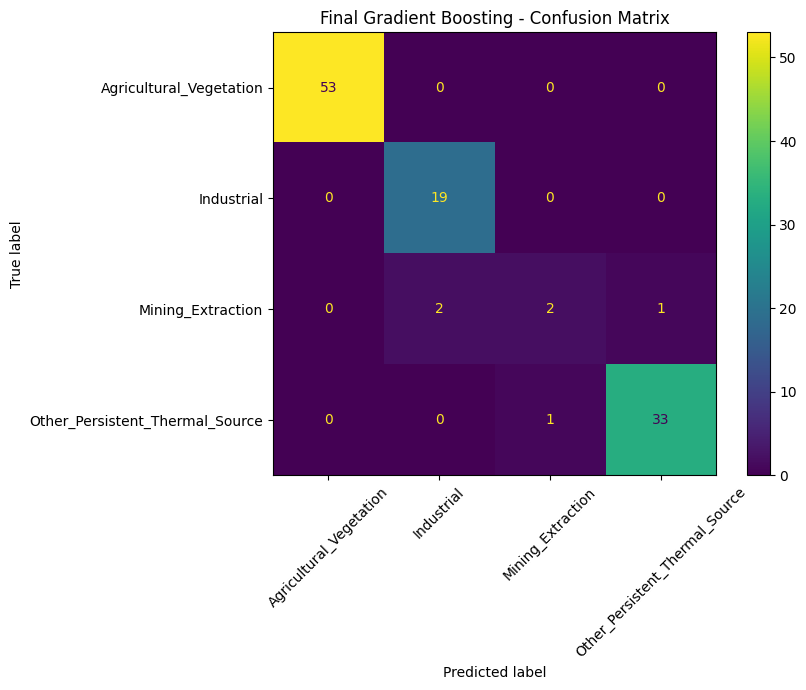

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Final Gradient Boosting - Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# INSPECT MINING TEST PREDICTIONS
# ============================================================

test_results = X_test.copy()

test_results["ACTUAL_LABEL"] = y_test.values
test_results["PREDICTED_LABEL"] = final_pred

mining_test = test_results[
    test_results["ACTUAL_LABEL"] == "Mining_Extraction"
].copy()

print("Mining samples in test set:", len(mining_test))

display(mining_test)

Mining samples in test set: 5


,total_detections,unique_days,unique_months,mean_FRP,max_FRP,active_duration_days,distance_to_industrial_km,distance_to_power_km,distance_to_mining_km,distance_to_fuel_storage_km,...,mean_precipitation,total_precipitation,mean_solar_radiation,weather_observations,first_detection_year,first_detection_month,last_detection_year,last_detection_month,ACTUAL_LABEL,PREDICTED_LABEL
270,17,16,8,0.757647,1.34,717,0.811132,7.102050,0.590721,NaN,...,0.000005,0.000093,1.989210e+07,17.0,2024,1,2025,12,Mining_Extraction,Mining_Extraction
247,551,333,18,1.355699,6.00,730,1.250698,8.348245,0.106898,NaN,...,0.000067,0.035711,2.108863e+07,535.0,2024,1,2025,12,Mining_Extraction,Other_Persistent_Thermal_Source
1,514,269,21,1.131848,4.24,727,12.644410,410.451406,0.829036,4.538796,...,0.000063,0.029516,1.908665e+07,469.0,2024,1,2025,12,Mining_Extraction,Mining_Extraction
252,377,285,22,1.302971,9.56,731,0.078169,12.829935,0.990898,NaN,...,0.000928,0.349805,2.037227e+07,377.0,2024,1,2025,12,Mining_Extraction,Industrial
337,14,14,6,0.879286,3.21,294,0.045555,5.714988,0.234171,NaN,...,0.000354,0.004950,2.163087e+07,14.0,2024,1,2024,11,Mining_Extraction,Industrial


In [ ]:
# ============================================================
# MINING TEST CASES + ORIGINAL DATA
# ============================================================

mining_indices = y_test[
    y_test == "Mining_Extraction"
].index

mining_original = df.loc[
    mining_indices
].copy()

mining_original["PREDICTED_LABEL"] = final_pred[
    y_test.values == "Mining_Extraction"
]

cols = [
    "HOTSPOT_ID",
    "hotspot_latitude",
    "hotspot_longitude",

    "FINAL_LABEL",
    "PREDICTED_LABEL",

    "dominant_land_cover",

    "distance_to_industrial_km",
    "distance_to_mining_km",
    "distance_to_power_km",

    "lc_bare_ratio",
    "lc_built_ratio",
    "lc_crops_ratio",

    "unique_days",
    "unique_months"
]

cols = [
    c for c in cols
    if c in mining_original.columns
]

display(
    mining_original[cols]
)

,HOTSPOT_ID,hotspot_latitude,hotspot_longitude,FINAL_LABEL,PREDICTED_LABEL,dominant_land_cover,distance_to_industrial_km,distance_to_mining_km,distance_to_power_km,lc_bare_ratio,lc_built_ratio,lc_crops_ratio,unique_days,unique_months
270,38792,19.108664,73.042225,Mining_Extraction,Mining_Extraction,shrub_and_scrub,0.811132,0.590721,7.102050,0.000000,0.000000,0.0,16,8
247,38636,19.102043,73.052459,Mining_Extraction,Other_Persistent_Thermal_Source,trees,1.250698,0.106898,8.348245,0.000000,0.413084,0.0,333,18
1,27,26.876586,73.515424,Mining_Extraction,Mining_Extraction,bare,12.644410,0.829036,410.451406,0.712154,0.287846,0.0,269,21
252,38646,15.658527,73.988879,Mining_Extraction,Industrial,trees,0.078169,0.990898,12.829935,0.000000,0.395225,0.0,285,22
337,39494,15.278957,74.148686,Mining_Extraction,Industrial,bare,0.045555,0.234171,5.714988,0.857143,0.142857,0.0,14,6


In [ ]:
# ============================================================
# REPEATED STRATIFIED TESTING
# ============================================================

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

sss = StratifiedShuffleSplit(
    n_splits=10,
    test_size=0.20,
    random_state=42
)

scores = []

for i, (train_idx, test_idx) in enumerate(
    sss.split(X, y),
    start=1
):

    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]

    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_tr, y_tr)

    pred = pipe.predict(X_te)

    scores.append({
        "Split": i,
        "Accuracy": accuracy_score(y_te, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_te, pred),
        "Macro_F1": f1_score(
            y_te,
            pred,
            average="macro"
        )
    })

repeated_results = pd.DataFrame(scores)

display(
    repeated_results.round(4)
)

print("\n========== MEAN PERFORMANCE ==========")

print(
    repeated_results[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1"
        ]
    ].mean().round(4)
)

print("\n========== STD DEV ==========")

print(
    repeated_results[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1"
        ]
    ].std().round(4)
)

,Split,Accuracy,Balanced_Accuracy,Macro_F1
0,1,0.964,0.8426,0.8551
1,2,0.955,0.8779,0.8905
2,3,0.964,0.8368,0.8702
3,4,1.000,1.0000,1.0000
4,5,0.964,0.8795,0.8926
5,6,0.973,0.9295,0.9177
6,7,0.982,0.9426,0.9399
7,8,0.982,0.9000,0.9304
8,9,0.973,0.9353,0.9564
9,10,1.000,1.0000,1.0000



========== MEAN PERFORMANCE ==========
Accuracy             0.9757
Balanced_Accuracy    0.9144
Macro_F1             0.9253
dtype: float64

========== STD DEV ==========
Accuracy             0.0153
Balanced_Accuracy    0.0578
Macro_F1             0.0502
dtype: float64


In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

model = final_pipeline.named_steps["model"]
prep = final_pipeline.named_steps["preprocessor"]

feature_names = prep.get_feature_names_out()

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("========== TOP 25 FEATURES ==========")

display(
    feature_importance.head(25)
)

========== TOP 25 FEATURES ==========


,Feature,Importance
17,num__lc_crops_ratio,0.514007
6,num__distance_to_industrial_km,0.336495
8,num__distance_to_mining_km,0.062689
36,cat__dominant_land_cover_built,0.020980
19,num__lc_built_ratio,0.018442
38,cat__dominant_land_cover_shrub_and_scrub,0.007282
7,num__distance_to_power_km,0.006139
39,cat__dominant_land_cover_trees,0.005728
14,num__lc_trees_ratio,0.005451
13,num__lc_water_ratio,0.004848


In [ ]:
# ============================================================
# SPATIAL GROUPS FOR GEOGRAPHIC VALIDATION
# ============================================================

spatial_df = df.copy()

# Create approximately 0.5° × 0.5° geographic cells
spatial_df["lat_grid"] = np.floor(
    spatial_df["hotspot_latitude"] / 0.5
)

spatial_df["lon_grid"] = np.floor(
    spatial_df["hotspot_longitude"] / 0.5
)

spatial_df["spatial_group"] = (
    spatial_df["lat_grid"].astype(str)
    + "_"
    + spatial_df["lon_grid"].astype(str)
)

print(
    "Number of spatial groups:",
    spatial_df["spatial_group"].nunique()
)

print("\nHotspots per spatial group:")
print(
    spatial_df["spatial_group"]
    .value_counts()
    .describe()
)

Number of spatial groups: 182

Hotspots per spatial group:
count    182.000000
mean       3.032967
std        3.105691
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       17.000000
Name: count, dtype: float64


In [ ]:
# ============================================================
# SPATIAL CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

groups = spatial_df["spatial_group"]

X_spatial = X.copy()
y_spatial = y.copy()

group_cv = GroupKFold(
    n_splits=5
)

spatial_results = []

fold = 1

for train_idx, val_idx in group_cv.split(
    X_spatial,
    y_spatial,
    groups=groups
):

    print(f"\nSpatial Fold {fold}/5")

    X_tr = X_spatial.iloc[train_idx]
    X_val = X_spatial.iloc[val_idx]

    y_tr = y_spatial.iloc[train_idx]
    y_val = y_spatial.iloc[val_idx]

    # Check classes
    print("Training classes:")
    print(y_tr.value_counts())

    print("Validation classes:")
    print(y_val.value_counts())

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_tr,
        y_tr
    )

    pred = pipeline.predict(X_val)

    spatial_results.append({
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_val,
            pred
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            y_val,
            pred
        ),

        "Macro_F1": f1_score(
            y_val,
            pred,
            average="macro"
        ),

        "Weighted_F1": f1_score(
            y_val,
            pred,
            average="weighted"
        )
    })

    fold += 1


spatial_results_df = pd.DataFrame(
    spatial_results
)

print("\n==========================================")
print("       SPATIAL CROSS-VALIDATION")
print("==========================================")

display(
    spatial_results_df.round(4)
)

print("\n========== MEAN ==========")

display(
    spatial_results_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ]
    ].mean().round(4)
)

print("\n========== STD ==========")

display(
    spatial_results_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ]
    ].std().round(4)
)


Spatial Fold 1/5
Training classes:
FINAL_LABEL
Agricultural_Vegetation            210
Other_Persistent_Thermal_Source    137
Industrial                          75
Mining_Extraction                   19
Name: count, dtype: int64
Validation classes:
FINAL_LABEL
Agricultural_Vegetation            56
Other_Persistent_Thermal_Source    33
Industrial                         17
Mining_Extraction                   5
Name: count, dtype: int64

Spatial Fold 2/5
Training classes:
FINAL_LABEL
Agricultural_Vegetation            208
Other_Persistent_Thermal_Source    144
Industrial                          69
Mining_Extraction                   20
Name: count, dtype: int64
Validation classes:
FINAL_LABEL
Agricultural_Vegetation            58
Other_Persistent_Thermal_Source    26
Industrial                         23
Mining_Extraction                   4
Name: count, dtype: int64

Spatial Fold 3/5
Training classes:
FINAL_LABEL
Agricultural_Vegetation            215
Other_Persistent_Thermal_Source  

,Fold,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,1,0.9550,0.8701,0.8701,0.9550
1,2,0.9820,0.8750,0.9062,0.9794
2,3,0.9545,0.8452,0.8741,0.9479
3,4,0.9909,0.9722,0.9822,0.9907
4,5,0.9455,0.8210,0.8452,0.9418



========== MEAN ==========


,0
Accuracy,0.9656
Balanced_Accuracy,0.8767
Macro_F1,0.8956
Weighted_F1,0.9629



========== STD ==========


,0
Accuracy,0.0197
Balanced_Accuracy,0.0576
Macro_F1,0.0531
Weighted_F1,0.0211


In [ ]:
# ============================================================
# FINAL MODEL FEATURE IMPORTANCE
# ============================================================

# Train final model on the full training portion
final_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(
    X_train,
    y_train
)

# Extract model + preprocessing
model = final_pipeline.named_steps["model"]
prep = final_pipeline.named_steps["preprocessor"]

# Feature names after preprocessing
feature_names = prep.get_feature_names_out()

# Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("========== TOP 30 FEATURES ==========")

display(
    feature_importance.head(30)
)

========== TOP 30 FEATURES ==========


,Feature,Importance
0,num__lc_crops_ratio,0.514007
1,num__distance_to_industrial_km,0.336495
2,num__distance_to_mining_km,0.062689
3,cat__dominant_land_cover_built,0.020980
4,num__lc_built_ratio,0.018442
5,cat__dominant_land_cover_shrub_and_scrub,0.007282
6,num__distance_to_power_km,0.006139
7,cat__dominant_land_cover_trees,0.005728
8,num__lc_trees_ratio,0.005451
9,num__lc_water_ratio,0.004848


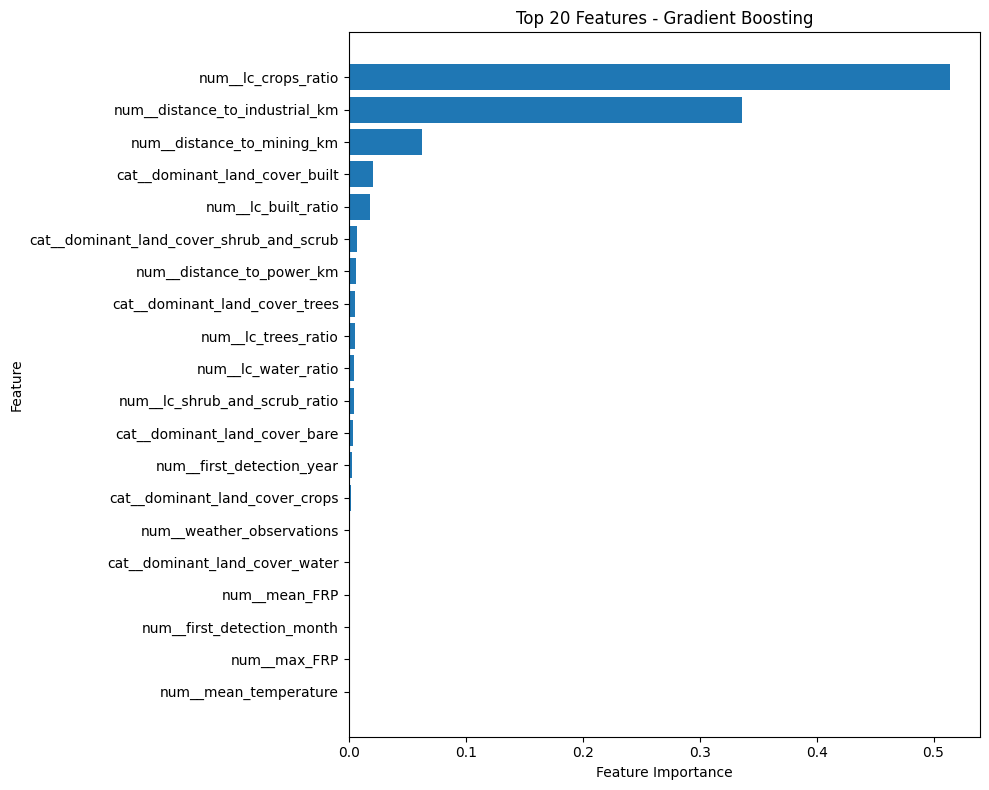

In [ ]:
# ============================================================
# TOP 20 FEATURE IMPORTANCE
# ============================================================

top20 = feature_importance.head(20).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Gradient Boosting")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TOP 30 FEATURES USED BY THE FINAL MODEL
# ============================================================

model = final_pipeline.named_steps["model"]
prep = final_pipeline.named_steps["preprocessor"]

feature_names = prep.get_feature_names_out()
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(30))

,Feature,Importance
0,num__lc_crops_ratio,0.514007
1,num__distance_to_industrial_km,0.336495
2,num__distance_to_mining_km,0.062689
3,cat__dominant_land_cover_built,0.020980
4,num__lc_built_ratio,0.018442
5,cat__dominant_land_cover_shrub_and_scrub,0.007282
6,num__distance_to_power_km,0.006139
7,cat__dominant_land_cover_trees,0.005728
8,num__lc_trees_ratio,0.005451
9,num__lc_water_ratio,0.004848


In [ ]:
import joblib

joblib.dump(
    final_pipeline,
    "/content/drive/MyDrive/DataSetForpython/FINAL_GRADIENT_BOOSTING_EVALUATED.pkl"
)

print("✅ Evaluated model saved successfully!")

✅ Evaluated model saved successfully!


In [ ]:
from sklearn.base import clone
import joblib

# Create a fresh copy of the best pipeline
final_deployment_pipeline = clone(final_pipeline)

# Train on all 552 hotspots
final_deployment_pipeline.fit(X, y)

# Save final model
model_path = "/content/drive/MyDrive/DataSetForpython/FINAL_GRADIENT_BOOSTING_MODEL.pkl"

joblib.dump(final_deployment_pipeline, model_path)

print("✅ FINAL DEPLOYMENT MODEL SAVED!")
print("Path:", model_path)

✅ FINAL DEPLOYMENT MODEL SAVED!
Path: /content/drive/MyDrive/DataSetForpython/FINAL_GRADIENT_BOOSTING_MODEL.pkl
